# Lap-Level Race Analysis

This notebook analyzes lap-by-lap performance for a Formula 1 race using FastF1. The analysis focuses on lap times, tyre strategy, race pace, and performance trends throughout the session.

In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import os
import sys
project_root=os.path.abspath("..")
sys.path.insert(0,project_root)


## Load Race Session

Load the selected Grand Prix session using the FastF1 data loader.

In [3]:
from src.data.fastf1_loader import load_session

session = load_session(
    2024,
    "British Grand Prix",
    "R",
)

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 10)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '55', '27', '18', '14', '23', '22', '2', '20', '3', '1

## Lap Time Analysis

Explore lap times to identify consistency, performance trends, and significant pace changes during the race.

In [4]:
laps = session.laps
print(laps.head())
print(laps.shape)

                    Time Driver DriverNumber                LapTime  \
0 0 days 00:59:51.778000    HAM           44 0 days 00:01:36.034000   
1 0 days 01:01:23.198000    HAM           44 0 days 00:01:31.420000   
2 0 days 01:02:54.914000    HAM           44 0 days 00:01:31.716000   
3 0 days 01:04:26.902000    HAM           44 0 days 00:01:31.988000   
4 0 days 01:05:58.579000    HAM           44 0 days 00:01:31.677000   

   LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
0        1.0    1.0        NaT       NaT                    NaT   
1        2.0    1.0        NaT       NaT 0 days 00:00:29.249000   
2        3.0    1.0        NaT       NaT 0 days 00:00:29.287000   
3        4.0    1.0        NaT       NaT 0 days 00:00:29.554000   
4        5.0    1.0        NaT       NaT 0 days 00:00:29.469000   

             Sector2Time  ... FreshTyre      Team           LapStartTime  \
0 0 days 00:00:37.703000  ...      True  Mercedes 0 days 00:58:15.512000   
1 0 days 00:00:37.

In [5]:
ver_laps = laps.pick_driver("VER")
print(len(ver_laps))
ver_laps[
    [
     "LapNumber",
        "LapTime",
        "IsAccurate",
        "Compound",
        "TyreLife",
        "PitInTime",
        "PitOutTime",
        "TrackStatus"   
    ]
].head(15)

c:\Users\mehra\OneDrive\Desktop\RaceIntel\venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


52


,LapNumber,LapTime,IsAccurate,Compound,TyreLife,PitInTime,PitOutTime,TrackStatus
52,1.0,0 days 00:01:36.711000,False,MEDIUM,1.0,NaT,NaT,1
53,2.0,0 days 00:01:31.773000,True,MEDIUM,2.0,NaT,NaT,1
54,3.0,0 days 00:01:32.200000,True,MEDIUM,3.0,NaT,NaT,1
55,4.0,0 days 00:01:31.933000,True,MEDIUM,4.0,NaT,NaT,1
56,5.0,0 days 00:01:31.778000,True,MEDIUM,5.0,NaT,NaT,1
57,6.0,0 days 00:01:31.711000,True,MEDIUM,6.0,NaT,NaT,1
58,7.0,0 days 00:01:31.935000,True,MEDIUM,7.0,NaT,NaT,1
59,8.0,0 days 00:01:32.038000,True,MEDIUM,8.0,NaT,NaT,1
60,9.0,0 days 00:01:31.883000,True,MEDIUM,9.0,NaT,NaT,1
61,10.0,0 days 00:01:31.661000,True,MEDIUM,10.0,NaT,NaT,1


In [6]:
ver_valid=ver_laps[ver_laps["IsAccurate"]]
fastest_lap=ver_valid.loc[ver_valid["LapTime"].idxmin()]
fastest_lap[["LapNumber","LapTime","Compound","TyreLife"]]

LapNumber                      48.0
LapTime      0 days 00:01:28.952000
Compound                       HARD
TyreLife                       10.0
dtype: object

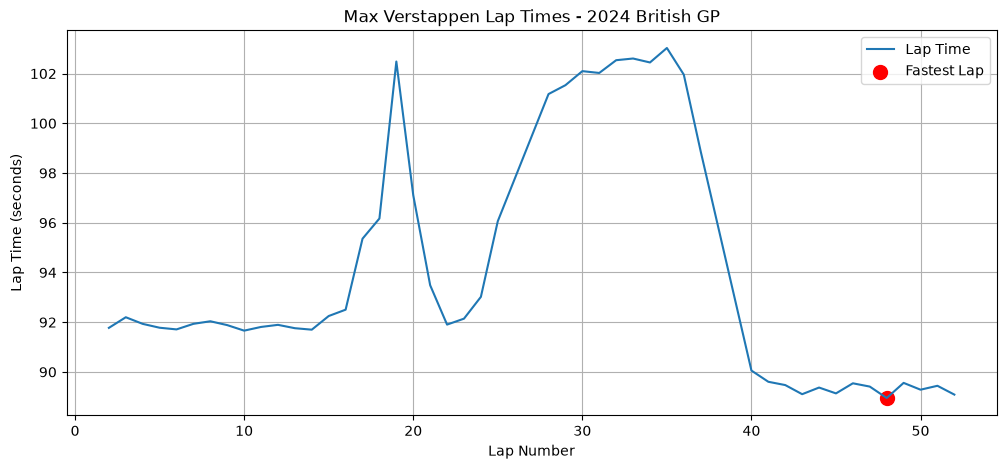

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    ver_valid["LapNumber"],
    ver_valid["LapTime"].dt.total_seconds(),
    label="Lap Time"
)

fastest = ver_valid.loc[ver_valid["LapTime"].idxmin()]

plt.scatter(
    fastest["LapNumber"],
    fastest["LapTime"].total_seconds(),
    color="red",
    s=100,
    label="Fastest Lap"
)

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Max Verstappen Lap Times - 2024 British GP")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
ver_laps[
    ["LapNumber", "LapTime", "TrackStatus", "PitInTime", "PitOutTime", "Compound"]
][15:40]

,LapNumber,LapTime,TrackStatus,PitInTime,PitOutTime,Compound
67,16.0,0 days 00:01:32.504000,1,NaT,NaT,MEDIUM
68,17.0,0 days 00:01:35.359000,1,NaT,NaT,MEDIUM
69,18.0,0 days 00:01:36.172000,1,NaT,NaT,MEDIUM
70,19.0,0 days 00:01:42.485000,1,NaT,NaT,MEDIUM
71,20.0,0 days 00:01:37.108000,1,NaT,NaT,MEDIUM
72,21.0,0 days 00:01:33.488000,1,NaT,NaT,MEDIUM
73,22.0,0 days 00:01:31.904000,1,NaT,NaT,MEDIUM
74,23.0,0 days 00:01:32.143000,1,NaT,NaT,MEDIUM
75,24.0,0 days 00:01:33.020000,1,NaT,NaT,MEDIUM
76,25.0,0 days 00:01:36.063000,1,NaT,NaT,MEDIUM


In [9]:
ver_laps[
    ["LapNumber", "LapTime", "TrackStatus", "PitInTime", "PitOutTime", "Compound"]
][15:40]

,LapNumber,LapTime,TrackStatus,PitInTime,PitOutTime,Compound
67,16.0,0 days 00:01:32.504000,1,NaT,NaT,MEDIUM
68,17.0,0 days 00:01:35.359000,1,NaT,NaT,MEDIUM
69,18.0,0 days 00:01:36.172000,1,NaT,NaT,MEDIUM
70,19.0,0 days 00:01:42.485000,1,NaT,NaT,MEDIUM
71,20.0,0 days 00:01:37.108000,1,NaT,NaT,MEDIUM
72,21.0,0 days 00:01:33.488000,1,NaT,NaT,MEDIUM
73,22.0,0 days 00:01:31.904000,1,NaT,NaT,MEDIUM
74,23.0,0 days 00:01:32.143000,1,NaT,NaT,MEDIUM
75,24.0,0 days 00:01:33.020000,1,NaT,NaT,MEDIUM
76,25.0,0 days 00:01:36.063000,1,NaT,NaT,MEDIUM


In [10]:
ver_laps["LapTime_sec"]=ver_laps["LapTime"].dt.total_seconds()

C:\Users\mehra\AppData\Local\Temp\ipykernel_13692\2780174862.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ver_laps["LapTime_sec"]=ver_laps["LapTime"].dt.total_seconds()


In [11]:
ver_laps[["LapNumber","LapTime","LapTime_sec"]].head()

,LapNumber,LapTime,LapTime_sec
52,1.0,0 days 00:01:36.711000,96.711
53,2.0,0 days 00:01:31.773000,91.773
54,3.0,0 days 00:01:32.200000,92.200
55,4.0,0 days 00:01:31.933000,91.933
56,5.0,0 days 00:01:31.778000,91.778


In [12]:
ver_laps["PitLap"] = ver_laps["PitInTime"].notna() | ver_laps["PitOutTime"].notna()

C:\Users\mehra\AppData\Local\Temp\ipykernel_13692\4100857667.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ver_laps["PitLap"] = ver_laps["PitInTime"].notna() | ver_laps["PitOutTime"].notna()


In [13]:
ver_laps[
    ["LapNumber","PitLap","PitInTime","PitOutTime"]
]

,LapNumber,PitLap,PitInTime,PitOutTime
52,1.0,False,NaT,NaT
53,2.0,False,NaT,NaT
54,3.0,False,NaT,NaT
55,4.0,False,NaT,NaT
56,5.0,False,NaT,NaT
57,6.0,False,NaT,NaT
58,7.0,False,NaT,NaT
59,8.0,False,NaT,NaT
60,9.0,False,NaT,NaT
61,10.0,False,NaT,NaT


In [14]:
ver_laps["Compound"].value_counts()

Compound
MEDIUM          26
HARD            14
INTERMEDIATE    12
Name: count, dtype: int64

In [15]:
ver_laps["LapTime_sec"].describe()

count     52.000000
mean      95.163923
std        6.702657
min       88.952000
25%       91.259750
50%       92.090500
75%       99.445750
max      119.169000
Name: LapTime_sec, dtype: float64

In [16]:
fastest = ver_laps.loc[
    ver_laps["LapTime_sec"].idxmin()
]

fastest

Time                      0 days 02:14:46.890000
Driver                                       VER
DriverNumber                                   1
LapTime                   0 days 00:01:28.952000
LapNumber                                   48.0
Stint                                        3.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:28.807000
Sector2Time               0 days 00:00:36.166000
Sector3Time               0 days 00:00:23.979000
Sector1SessionTime        0 days 02:13:46.800000
Sector2SessionTime        0 days 02:14:22.966000
Sector3SessionTime        0 days 02:14:46.945000
SpeedI1                                    316.0
SpeedI2                                    266.0
SpeedFL                                    250.0
SpeedST                                    327.0
IsPersonalBest                              True
Compound                                    HARD
TyreLife            

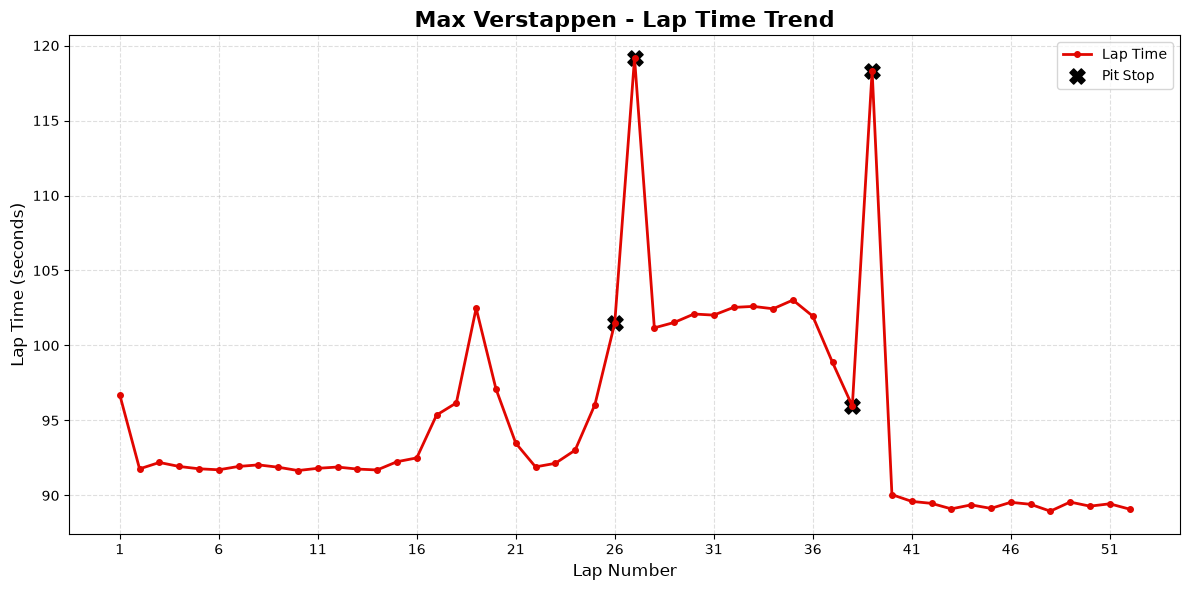

In [17]:
pit = ver_laps[ver_laps["PitLap"]]

plt.figure(figsize=(12,6))

plt.plot(
    ver_laps["LapNumber"],
    ver_laps["LapTime_sec"],
    color="#E10600",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Lap Time"
)

plt.scatter(
    pit["LapNumber"],
    pit["LapTime_sec"],
    color="black",
    marker="X",
    s=120,
    label="Pit Stop"
)

plt.title(
    "Max Verstappen - Lap Time Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Lap Number", fontsize=12)
plt.ylabel("Lap Time (seconds)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(range(1, int(ver_laps["LapNumber"].max()) + 1, 5))

plt.legend()

plt.tight_layout()
plt.show()

In [18]:
valid_laps = session.laps.pick_accurate()

fastest_laps = (
    valid_laps
    .groupby("Driver")["LapTime"]
    .min()
    .reset_index()
    .sort_values("LapTime")
)

fastest_laps.head(10)

,Driver,LapTime
13,SAI,0 days 00:01:28.293000
10,PIA,0 days 00:01:28.748000
17,VER,0 days 00:01:28.952000
7,NOR,0 days 00:01:29.262000
3,HAM,0 days 00:01:29.438000
9,PER,0 days 00:01:29.707000
1,ALO,0 days 00:01:29.710000
0,ALB,0 days 00:01:29.718000
5,LEC,0 days 00:01:29.748000
4,HUL,0 days 00:01:29.836000


In [19]:
ver_fastest = (
    ver_laps
    .pick_accurate()
    .loc[
        ver_laps.pick_accurate()["LapTime"].idxmin()
    ]
)

ver_fastest

Time                      0 days 02:14:46.890000
Driver                                       VER
DriverNumber                                   1
LapTime                   0 days 00:01:28.952000
LapNumber                                   48.0
Stint                                        3.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:28.807000
Sector2Time               0 days 00:00:36.166000
Sector3Time               0 days 00:00:23.979000
Sector1SessionTime        0 days 02:13:46.800000
Sector2SessionTime        0 days 02:14:22.966000
Sector3SessionTime        0 days 02:14:46.945000
SpeedI1                                    316.0
SpeedI2                                    266.0
SpeedFL                                    250.0
SpeedST                                    327.0
IsPersonalBest                              True
Compound                                    HARD
TyreLife            

In [20]:
clean_ver_laps = ver_laps[
    (~ver_laps["PitLap"]) &
    (ver_laps["LapTime_sec"].notna())
]

In [21]:
clean_ver_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTime_sec,PitLap
52,0 days 00:59:52.455000,VER,1,0 days 00:01:36.711000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:37.975000,...,0 days 00:58:15.512000,2024-07-07 14:03:12.541,1,3.0,False,,False,False,96.711,False
53,0 days 01:01:24.228000,VER,1,0 days 00:01:31.773000,2.0,1.0,NaT,NaT,0 days 00:00:29.612000,0 days 00:00:37.222000,...,0 days 00:59:52.455000,2024-07-07 14:04:49.484,1,3.0,False,,False,True,91.773,False
54,0 days 01:02:56.428000,VER,1,0 days 00:01:32.200000,3.0,1.0,NaT,NaT,0 days 00:00:29.672000,0 days 00:00:37.216000,...,0 days 01:01:24.228000,2024-07-07 14:06:21.257,1,3.0,False,,False,True,92.200,False
55,0 days 01:04:28.361000,VER,1,0 days 00:01:31.933000,4.0,1.0,NaT,NaT,0 days 00:00:29.626000,0 days 00:00:37.090000,...,0 days 01:02:56.428000,2024-07-07 14:07:53.457,1,3.0,False,,False,True,91.933,False
56,0 days 01:06:00.139000,VER,1,0 days 00:01:31.778000,5.0,1.0,NaT,NaT,0 days 00:00:29.608000,0 days 00:00:37.007000,...,0 days 01:04:28.361000,2024-07-07 14:09:25.390,1,3.0,False,,False,True,91.778,False


In [22]:
clean_ver_laps["LapTime_sec"].describe()

count     48.000000
mean      94.033125
std        4.787233
min       88.952000
25%       89.943000
50%       91.934000
75%       96.810250
max      103.029000
Name: LapTime_sec, dtype: float64

In [23]:
ver_laps["Compound"].value_counts()

Compound
MEDIUM          26
HARD            14
INTERMEDIATE    12
Name: count, dtype: int64

In [24]:
stints = (
    ver_laps
    .groupby(["Stint", "Compound"])
    .size()
    .reset_index(name="LapCount")
)

stints

,Stint,Compound,LapCount
0,1.0,MEDIUM,26
1,2.0,INTERMEDIATE,12
2,3.0,HARD,14


In [25]:
(
    clean_ver_laps
    .groupby("Compound")["LapTime_sec"]
    .mean()
    .sort_values()
)

Compound
HARD             89.386923
MEDIUM           93.331240
INTERMEDIATE    101.827900
Name: LapTime_sec, dtype: float64

<Figure size 800x500 with 0 Axes>

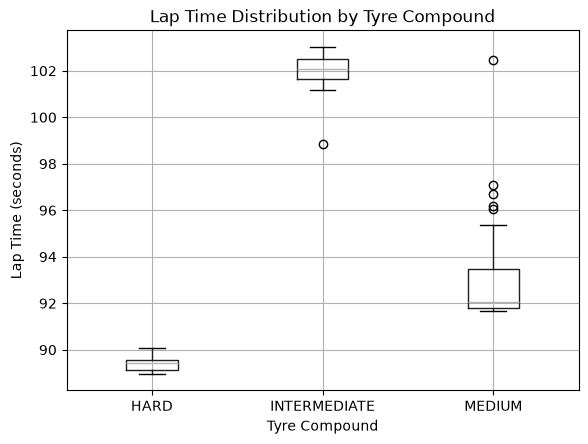

In [26]:
plt.figure(figsize=(8,5))

clean_ver_laps.boxplot(
    column="LapTime_sec",
    by="Compound"
)
plt.title("Lap Time Distribution by Tyre Compound")
plt.suptitle("")
plt.xlabel("Tyre Compound")
plt.ylabel("Lap Time (seconds)")
plt.show()

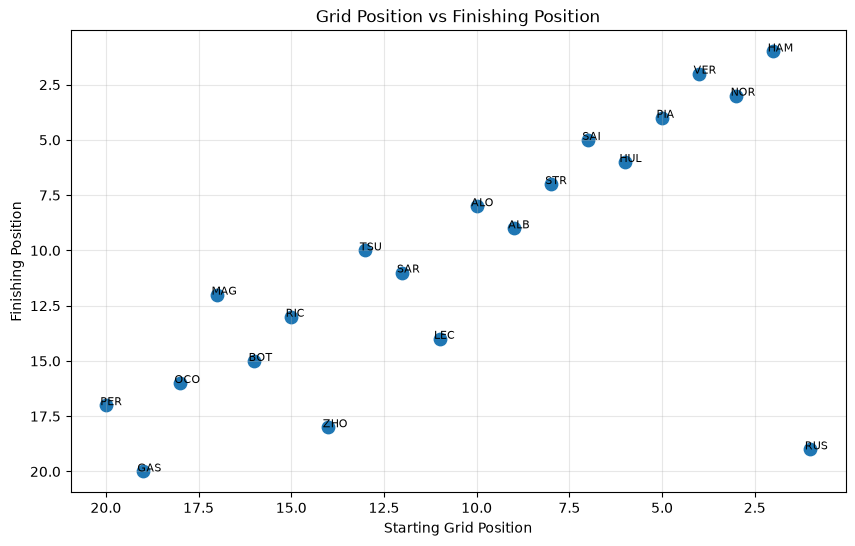

In [27]:
results = session.results

plt.figure(figsize=(10, 6))

plt.scatter(
    results["GridPosition"],
    results["Position"],
    s=80
)

for _, row in results.iterrows():
    plt.text(
        row["GridPosition"] + 0.15,
        row["Position"],
        row["Abbreviation"],
        fontsize=8
    )
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.title("Grid Position vs Finishing Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Finishing Position")
plt.grid(alpha=0.3)

plt.savefig(
    "../docs/phase_01/screenshots/grid_vs_finish.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

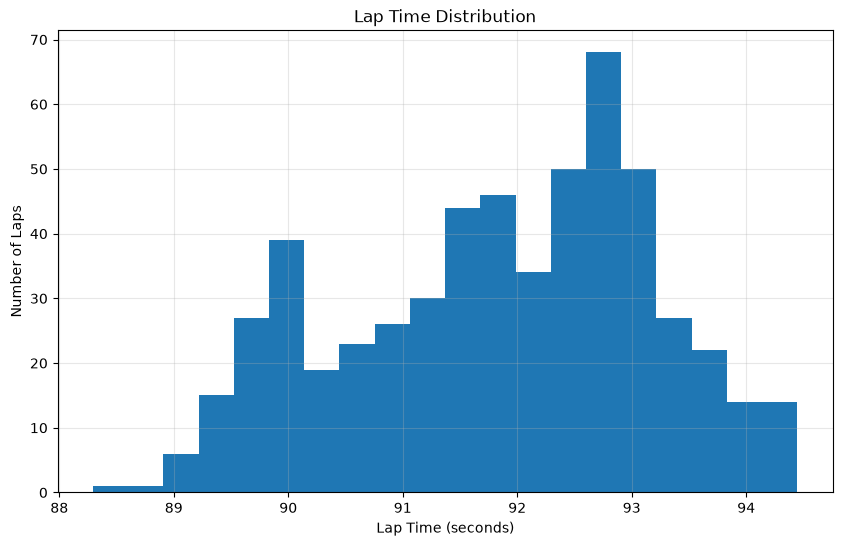

In [28]:
valid_laps = laps.pick_quicklaps()

plt.figure(figsize=(10, 6))

plt.hist(
    valid_laps["LapTime"].dt.total_seconds(),
    bins=20
)

plt.title("Lap Time Distribution")
plt.xlabel("Lap Time (seconds)")
plt.ylabel("Number of Laps")
plt.grid(alpha=0.3)

plt.savefig(
    "../docs/phase_01/screenshots/lap_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

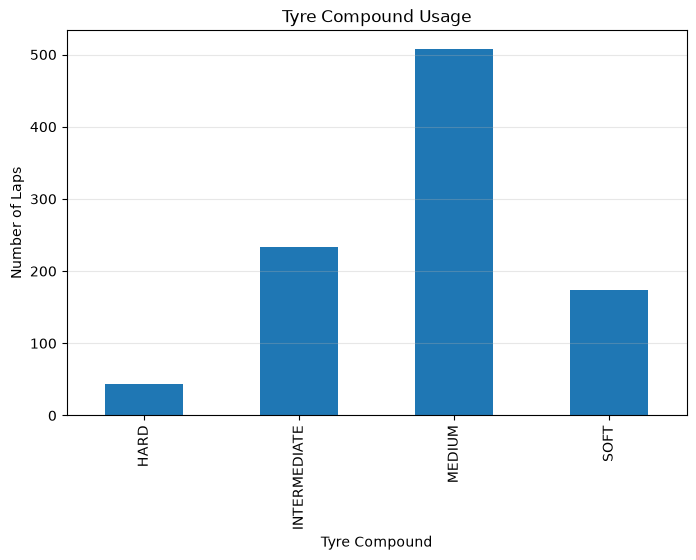

In [29]:
compound_counts = (
    laps["Compound"]
    .dropna()
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

compound_counts.plot(kind="bar")

plt.title("Tyre Compound Usage")
plt.xlabel("Tyre Compound")
plt.ylabel("Number of Laps")
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../docs/phase_01/screenshots/tyre_strategy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

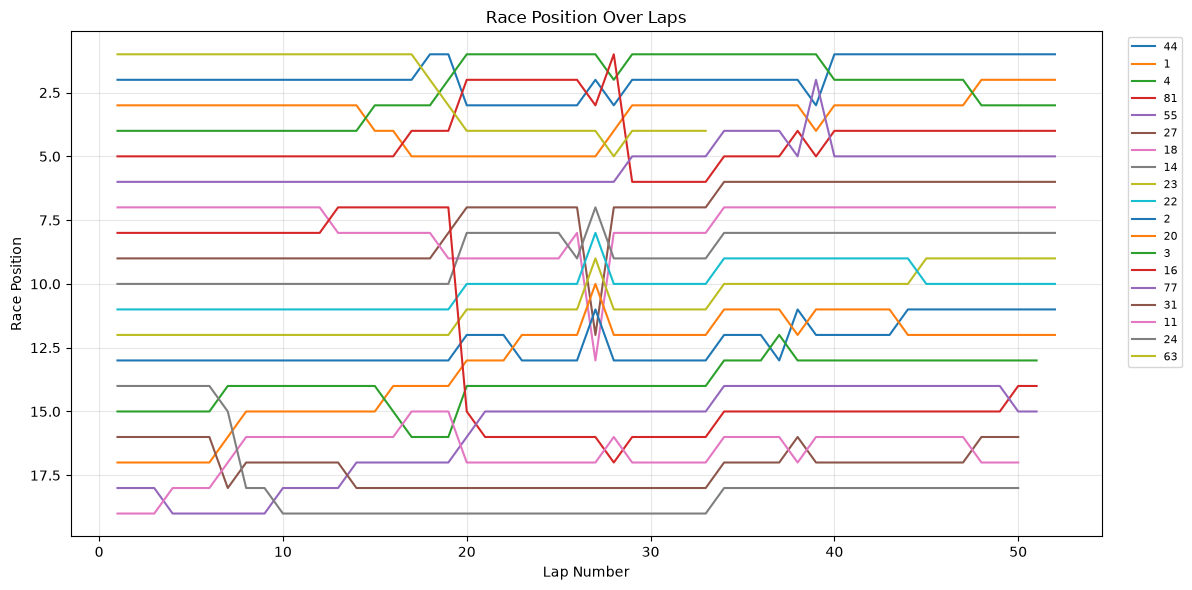

In [31]:
plt.figure(figsize=(12, 6))

for drv in session.drivers:
    driver_laps = session.laps.pick_drivers(drv)

    # Skip drivers with no lap data
    if driver_laps.empty:
        continue

    plt.plot(
        driver_laps["LapNumber"],
        driver_laps["Position"],
        label=drv
    )

plt.gca().invert_yaxis()

plt.title("Race Position Over Laps")
plt.xlabel("Lap Number")
plt.ylabel("Race Position")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    ncol=1
)

plt.tight_layout()

plt.savefig(
    "../docs/phase_01/screenshots/race_position.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Summary

This notebook provides an overview of lap-by-lap race performance and tyre strategy, forming the basis for later telemetry and predictive analyses in the RaceIntel project.